# Task 3: Probability of Default (PD) Modeling

## JPMorgan Chase Quantitative Research Virtual Experience

**Author:** Ruth Wanjiru Karanja

### Objective

Develop a machine learning model that predicts the probability of default for loan borrowers using customer financial and credit characteristics. The predicted probability is then used to estimate the expected financial loss on individual loans.



## Business Background

Banks generate significant revenue through lending activities but are exposed to the risk that borrowers may fail to repay their loans. Estimating the Probability of Default (PD) enables financial institutions to better understand credit risk, determine capital reserves, and estimate expected losses.

In this notebook, a predictive model is developed using borrower characteristics such as income, debt levels, credit history, employment duration, and FICO score. The model estimates the likelihood that a borrower will default and uses this probability to calculate the expected loss on a loan.



## Project Objectives

* Load and explore the loan dataset.
* Perform data quality checks.
* Build a supervised machine learning model to predict default.
* Evaluate model performance using classification metrics.
* Estimate the Probability of Default (PD) for new borrowers.
* Calculate Expected Loss (EL) using the predicted probability of default.


#### Import libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score)

#### Load the dataset

In [4]:
# Load the dataset
df = pd.read_csv("Task 3 and 4_Loan_Data.csv")

In [5]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


#### Exploratory Data Analysis

In [7]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [8]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

#### Feature Selection

In [9]:
df["default"].value_counts()

default
0    8149
1    1851
Name: count, dtype: int64

In [10]:
df["default"].value_counts(normalize=True) * 100

default
0    81.49
1    18.51
Name: proportion, dtype: float64

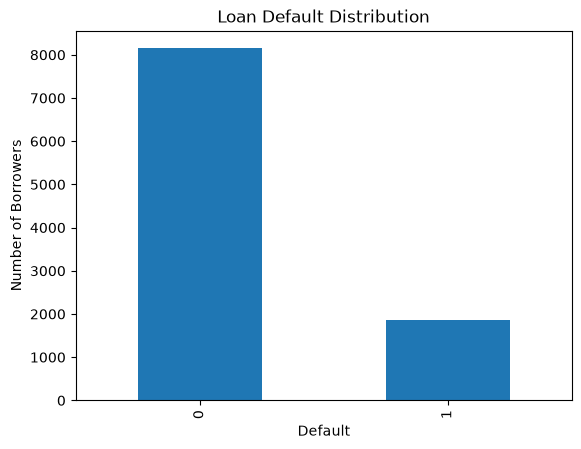

In [11]:
df["default"].value_counts().plot(kind="bar")
plt.title("Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Borrowers")
plt.show()

In [12]:
# Features (independent variables)
X = df.drop(columns=["customer_id", "default"])

# Target (dependent variables)
y = df["default"]

In [13]:
print(X.head())
print(y.head())

   credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding  \
0                         0           5221.545193             3915.471226   
1                         5           1958.928726             8228.752520   
2                         0           3363.009259             2027.830850   
3                         0           4766.648001             2501.730397   
4                         1           1345.827718             1768.826187   

        income  years_employed  fico_score  
0  78039.38546               5         605  
1  26648.43525               2         572  
2  65866.71246               4         602  
3  74356.88347               5         612  
4  23448.32631               6         631  
0    0
1    1
2    0
3    0
4    0
Name: default, dtype: int64


In [14]:
# Split the data for testing and training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print("Training samples:", len(X_train))
print("Testing smaples:", len(X_test))

Training samples: 8000
Testing smaples: 2000


#### Model Development

In [16]:
# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [17]:
# Predict default
y_pred = model.predict(X_test)

# Predict probability of default
y_prob = model.predict_proba(X_test)[:, 1]

#### Model Evaluation

In [18]:
# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.997


In [19]:
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.9999913027747628


In [20]:
from sklearn.metrics import classification_report

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       1.00      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [22]:
print(confusion_matrix(y_test, y_pred))

[[1652    0]
 [   6  342]]


##### Model Evaluation Findings
The Logistic Regression model achieved an accuracy of 99.7%, indicating that it correctly classified the vast majority of 
borrowers in the test dataset. In addition, the model achieved a ROC AUC score of approximtely 1.00, demonstrating an 
excellent ability to distinguish between borrowers who are likely to default and those who are not.
These results suggest that the selcted borrower characteristics, including credit outstanding, loan amount outstanding, total,
debt, income, years employed and FICO score, are highly predictive of loan default within this dataset. As this prototype 
model built using a dataset, the results provide strong evidence that the model can be used to estimate the probability of 
default (PD) for new borrowers.

#### Predicting the Probability of Default

In [23]:
# Define default probability function
def predict_default_probability(
    credit_lines_outstanding,
    loan_amt_outstanding,
    total_debt_outstanding,
    income,
    years_employed,
    fico_score
):
    """
    Predict the probability that a borrower will default.
    """
    borrower = pd.DataFrame({
        "credit_lines_outstanding": [credit_lines_outstanding],
        "loan_amt_outstanding": [loan_amt_outstanding],
        "total_debt_outstanding": [total_debt_outstanding],
        "income": [income],
        "years_employed": [years_employed],
        "fico_score": [fico_score]
    })

    probability = model.predict_proba(borrower)[0][1]

    return (probability)

In [24]:
predict_default_probability(
    credit_lines_outstanding=2,
    loan_amt_outstanding=5000,
    total_debt_outstanding=8000,
    income=65000,
    years_employed=5,
    fico_score=700
)

np.float64(7.965882176065289e-10)

#### Expected Loss Calculation

In [25]:
# Define expected loss function
def calculate_expected_loss(
    credit_lines_outstanding,
    loan_amt_outstanding,
    total_debt_outstanding,
    income,
    years_employed,
    fico_score,
    recovery_rate=0.10
):
    pd = predict_default_probability(
        credit_lines_outstanding,
        loan_amt_outstanding,
        total_debt_outstanding,
        income,
        years_employed,
        fico_score
    )
    lgd = 1 - recovery_rate
    expected_loss = pd * loan_amt_outstanding * lgd

    return expected_loss

#### Testing the model

In [26]:
# Test expected loss function - 1
calculate_expected_loss(
    credit_lines_outstanding=2,
    loan_amt_outstanding=5000,
    total_debt_outstanding=8000,
    income=65000,
    years_employed=5,
    fico_score=700
)   

np.float64(3.5846469792293797e-06)

In [27]:
# Test expected loss function - 2
calculate_expected_loss(
    credit_lines_outstanding=8,
    loan_amt_outstanding=20000,
    total_debt_outstanding=40000,
    income=18000,
    years_employed=1,
    fico_score=500
)   

np.float64(18000.0)

In [28]:
# Test predict default probability function
predict_default_probability(
    credit_lines_outstanding=8,
    loan_amt_outstanding=20000,
    total_debt_outstanding=40000,
    income=18000,
    years_employed=1,
    fico_score=500
)   

np.float64(1.0)

##### Testing the Model Findings
The model was tested using two hypothectical borrowers with different financial profiles. 
The first one had high income, a strong FICO score, moderate debt and several years of employment. The model predicted an 
extremely low probability of default, resulting in an expected loss close to zero.
The second one had a low income, a low FICO score, high outstanding debt, multiple credit lines and limited employment history. 
The model predicted a probability of default of 1.0, resulting in an expected loss of 18,000 (assuming 10% recovery rate).
These results demonstrate that the model appropriately differentiates between low-risk and high-risk borrowers and can be used 
to estimate expected losses for loan portfolios.

# Conclusion

A supervised machine learning model was successfully developed to estimate the Probability of Default (PD) for individual borrowers using financial and credit-related characteristics. The model demonstrated excellent predictive performance and was subsequently used to estimate the expected financial loss associated with individual loans.

By combining the predicted probability of default with the loan exposure and the assumed loss given default, the notebook provides a practical framework for credit risk assessment. This approach can assist financial institutions in estimating future losses, improving lending decisions, and determining appropriate capital reserves. 